# Results summary

Generates tables (copy-paste to LaTeX) and corner plots for the paper.

In [1]:
import os
from os.path import join
from datetime import datetime

import h5py
import numpy as np
import matplotlib.pyplot as plt

from candel.mock.ppc_mwcepheids import generate_ppc
from candel import load_config
from candel.pvdata import CepheidData, to_mwcepheids_config
from mwcepheids_plotting import plot_corner_getdist, plot_ppc
import scienceplots  # noqa

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
RESULTS = "../results"
FIGDIR = os.path.expanduser("~/Downloads")

# Run directory mapping: {tag: (label, path)}
RUNS = {
    # --- Main results (C22+C27) ---
    "fiducial": ("C22 + C27 + LMC + N4258 (disk prior, sel.)",
                 "forward/C22+C27_C22-mW+pi_C27-pi+mW_anc-NGC4258+LMC_dprior-disk"),
    "nosel+anc": ("C22 + C27 + LMC + N4258 (disk prior, no sel.)",
                  "forward/C22+C27_nosel_anc-NGC4258+LMC_dprior-disk"),
    "sel": ("C22 + C27 (disk prior, sel.)",
            "forward/C22+C27_C22-mW+pi_C27-pi+mW_dprior-disk"),
    "nosel": ("C22 + C27 (disk prior, no sel.)",
              "forward/C22+C27_nosel_dprior-disk"),
    "nosel+vol": ("C22 + C27 (unif-in-vol prior, no sel.)",
                  "forward/C22+C27_nosel_dprior-volume"),
    "nosel+vol+anc": ("C22 + C27 + LMC + N4258 (unif-in-vol prior, no sel.)",
                      "forward/C22+C27_nosel_anc-NGC4258+LMC_dprior-volume"),
    "nosel+vol+anc+wdpi": ("C22 + C27 + LMC + N4258 (unif-in-vol prior, no sel., wide $\\delta_\\varpi$)",
                           "forward/C22+C27_nosel_anc-NGC4258+LMC_dprior-volume_wide_dpi"),
    "wide_dpi": ("C22 + C27 + LMC + N4258 (disk prior, sel., wide $\\delta_\\varpi$)",
                 "forward/C22+C27_C22-mW+pi_C27-pi+mW_anc-NGC4258+LMC_dprior-disk_wide_dpi"),
    "spirals": ("C22 + C27 + LMC + N4258 (disk prior, sel., spiral arms)",
                "forward/C22+C27_C22-mW+pi_C27-pi+mW_anc-NGC4258+LMC_dprior-disk_spirals"),
    "R21": ("C22 + C27 (R21 $\\chi^2$)",
            "R21/C22+C27"),
    "R21+anc": ("C22 + C27 + LMC + N4258 (R21 $\\chi^2$)",
                "R21/C22+C27_anc-NGC4258+LMC"),
    # --- Scatter tests ---
    "shared+anc": ("Shared scatter C22 + C27 + LMC + N4258 (disk prior, sel.)",
                   "forward/C22+C27_C22-mW+pi_C27-pi+mW_anc-NGC4258+LMC_dprior-disk_shared_scatter"),
    "shared_noanc": ("Shared scatter C22 + C27 (disk prior, sel.)",
                     "forward/C22+C27_C22-mW+pi_C27-pi+mW_dprior-disk_shared_scatter"),
    "shared_fpi": ("C22 + C27 (shared $\\sigma_{\\rm int}$, free $f_\\varpi$)",
                   "forward/C22+C27_C22-mW+pi_C27-pi+mW_dprior-disk_free_f_pi_shared_scatter"),
    "separate+anc": ("separate scatter, + anchors",
                     "forward/C22+C27_C22-mW+pi_C27-pi+mW_anc-NGC4258+LMC_dprior-disk_separate_scatter"),
    # --- Individual campaigns ---
    "C22_sel": ("C22 (disk prior, sel.)",
                "forward/C22_C22-mW+pi_dprior-disk"),
    "C22_nosel": ("C22 (disk prior, no sel.)",
                  "forward/C22_nosel_dprior-disk"),
    "C22_sel+anc": ("C22 + LMC + N4258 (disk prior, sel.)",
                    "forward/C22_C22-mW+pi_anc-NGC4258+LMC_dprior-disk"),
    "C22_nosel+anc": ("C22 + LMC + N4258 (disk prior, no sel.)",
                      "forward/C22_nosel_anc-NGC4258+LMC_dprior-disk"),
    "C27_sel": ("C27 (disk prior, sel.)",
                "forward/C27_C27-pi+mW_dprior-disk"),
    "C27_nosel": ("C27 (disk prior, no sel.)",
                  "forward/C27_nosel_dprior-disk"),
    "C27_sel+anc": ("C27 + LMC + N4258 (disk prior, sel.)",
                    "forward/C27_C27-pi+mW_anc-NGC4258+LMC_dprior-disk"),
    "C27_nosel+anc": ("C27 + LMC + N4258 (disk prior, no sel.)",
                      "forward/C27_nosel_anc-NGC4258+LMC_dprior-disk"),
    "R21_C22": ("C22 (R21 $\\chi^2$)",
                "R21/C22"),
    "R21_C27": ("C27 (R21 $\\chi^2$)",
                "R21/C27"),
    "R21_C22+anc": ("C22 + LMC + N4258 (R21 $\\chi^2$)",
                    "R21/C22_anc-NGC4258+LMC"),
    "R21_C27+anc": ("C27 + LMC + N4258 (R21 $\\chi^2$)",
                    "R21/C27_anc-NGC4258+LMC"),
    # --- Q-index runs ---
    "Q": ("C22 + C27 (sel., Q index)",
          "forward/C22+C27_C22-mW+pi_C27-pi+mW_dprior-disk_Q"),
    "Q+anc": ("C22 + C27 + LMC + N4258 (sel., Q index)",
              "forward/C22+C27_C22-mW+pi_C27-pi+mW_anc-NGC4258+LMC_dprior-disk_Q"),
    # --- JWST Q-index runs (N4258 only, ID-matched) ---
    "Q_jwst_cW0": ("C22 + C27 + N4258 (JWST Q, $c_W = 0$)",
                   "forward/C22+C27_C22-mW+pi_C27-pi+mW_anc-NGC4258_dprior-disk_Q_c_W=0.0_jwst_marg_ev"),
    "Q_jwst": ("C22 + C27 + N4258 (JWST Q, $c_W$ free)",
               "forward/C22+C27_C22-mW+pi_C27-pi+mW_anc-NGC4258_dprior-disk_Q_jwst_marg_ev"),
}


def hdf5_path(tag):
    return join(RESULTS, RUNS[tag][1], "samples.hdf5")


def run_label(tag):
    return RUNS[tag][0]


def load_samples(tag):
    with h5py.File(hdf5_path(tag), "r") as f:
        grp = f["samples"] if "samples" in f else f
        return {k: grp[k][:] for k in grp.keys()}


# Verify all files exist
for tag, (label, path) in RUNS.items():
    fpath = hdf5_path(tag)
    if os.path.isfile(fpath):
        mtime = datetime.fromtimestamp(os.path.getmtime(fpath))
        print(f"  OK  {tag:<25s} {mtime:%Y-%m-%d %H:%M}  {label}")
    else:
        print(f"  MISSING  {tag:<25s} {'':>16s}  {label}")

## 1. Helpers

In [3]:
import subprocess


def summarise(tag, keys):
    """Return dict of {param: (mean, std, median, p16, p84)}."""
    samples = load_samples(tag)
    out = {}
    for k in keys:
        if k not in samples:
            continue
        arr = samples[k]
        if arr.ndim > 1:
            continue
        out[k] = {
            "mean": arr.mean(),
            "std": arr.std(),
            "median": np.median(arr),
            "p16": np.percentile(arr, 16),
            "p84": np.percentile(arr, 84),
        }
    return out


def fmt(val, err, ndp=3):
    """Format value +/- error as LaTeX string."""
    return f"${val:.{ndp}f} \\pm {err:.{ndp}f}$"


def latex_row(label, stats, keys, ndp=3, scale=None, ndp_per_key=None):
    """Return one LaTeX table row as a string.

    ndp_per_key : dict, optional
        {param: int} overrides ndp for specific keys.
    """
    if scale is None:
        scale = {}
    if ndp_per_key is None:
        ndp_per_key = {}
    if " (" in label:
        label = r"\makecell{" + label.replace(" (", r" \\ (") + "}"
    cells = [label]
    for k in keys:
        if k in stats:
            s = stats[k]
            f = scale.get(k, 1.0)
            dp = ndp_per_key.get(k, ndp)
            cells.append(fmt(s["mean"] * f, s["std"] * f, dp))
        else:
            cells.append("---")
    return " & ".join(cells) + r" \\"


def pbcopy(text):
    """Copy text to macOS clipboard."""
    subprocess.run(["pbcopy"], input=text.encode(), check=True)
    print("(copied to clipboard)")

## 2. Results tables

In [4]:
MAIN_KEYS = ["M_H_1", "b_W", "Z_W", "delta_pi", "sigma_int_C22", "sigma_int_C27",
             "sigma_int", "f_pi"]
MAIN_SCALE = {"delta_pi": 1000}

groups = [
    ["fiducial", "sel"],
    ["wide_dpi", "spirals", "R21", "R21+anc"],
    ["nosel+anc", "nosel", "nosel+vol", "nosel+vol+anc+wdpi", "nosel+vol+anc"],
    ["shared_fpi", "wide_dpi"],
]

header = f"{'Model':<55s}" + "".join(f"  {k:>18s}" for k in MAIN_KEYS)
print(header)
print("-" * len(header))

for gi, group in enumerate(groups):
    for tag in group:
        stats = summarise(tag, MAIN_KEYS)
        row = f"{run_label(tag):<55s}"
        for k in MAIN_KEYS:
            if k in stats:
                s = stats[k]
                f = MAIN_SCALE.get(k, 1.0)
                row += f"  {s['mean']*f:>8.3f} +/- {s['std']*f:.3f}"
            else:
                row += f"  {'---':>18s}"
        print(row)
    if gi < len(groups) - 1:
        print()

Model                                                                 M_H_1                 b_W                 Z_W            delta_pi       sigma_int_C22       sigma_int_C27           sigma_int                f_pi
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
C22 + C27 + LMC + N4258 (disk prior, sel.)                 -5.909 +/- 0.022    -3.307 +/- 0.030    -0.223 +/- 0.082   -12.449 +/- 5.267     0.071 +/- 0.022     0.040 +/- 0.016                 ---     1.000 +/- 0.000
C22 + C27 (disk prior, sel.)                               -5.889 +/- 0.040    -3.269 +/- 0.064    -0.266 +/- 0.176    -9.928 +/- 6.136     0.071 +/- 0.022     0.043 +/- 0.016                 ---     1.000 +/- 0.000

C22 + C27 + LMC + N4258 (disk prior, sel., wide $\delta_\varpi$)    -5.922 +/- 0.023    -3.315 +/- 0.031    -0.242 +/- 0.084   -17.162 

### Population hyperparameters

In [5]:
POP_KEYS = [
    "sigma_int_C22", "sigma_int_C27",
    "mu_logP_C22", "sigma_logP_C22",
    "mu_logP_C27", "sigma_logP_C27",
    "mu_OH_C22", "sigma_OH_C22",
    "mu_OH_C27", "sigma_OH_C27",
]

pop_tags = ["fiducial", "nosel+anc", "sel", "nosel"]

for tag in pop_tags:
    stats = summarise(tag, POP_KEYS)
    print(f"\n--- {run_label(tag)} ---")
    for k in POP_KEYS:
        if k in stats:
            s = stats[k]
            print(f"  {k:<25s}  {s['mean']:>8.4f} +/- {s['std']:.4f}")


--- C22 + C27 + LMC + N4258 (disk prior, sel.) ---
  sigma_int_C22                0.0708 +/- 0.0220
  sigma_int_C27                0.0403 +/- 0.0156
  mu_logP_C22                  0.5752 +/- 0.4283
  sigma_logP_C22               0.3991 +/- 0.1220
  mu_logP_C27                  0.7711 +/- 0.0350
  sigma_logP_C27               0.1529 +/- 0.0258
  mu_OH_C22                    0.1503 +/- 0.0221
  sigma_OH_C22                 0.1271 +/- 0.0178
  mu_OH_C27                    0.1340 +/- 0.0209
  sigma_OH_C27                 0.0762 +/- 0.0212

--- C22 + C27 + LMC + N4258 (disk prior, no sel.) ---
  sigma_int_C22                0.0679 +/- 0.0212
  sigma_int_C27                0.0386 +/- 0.0149
  mu_logP_C22                  1.1681 +/- 0.0288
  sigma_logP_C22               0.1844 +/- 0.0217
  mu_logP_C27                  0.7567 +/- 0.0311
  sigma_logP_C27               0.1480 +/- 0.0230
  mu_OH_C22                    0.1518 +/- 0.0218
  sigma_OH_C22                 0.1271 +/- 0.0181
  mu_OH_C27

### Anchor distance moduli

In [6]:
ANCHOR_KEYS = ["mu_LMC", "mu_NGC4258"]

# Geometric distance moduli (from config)
MU_GEOM = {"mu_LMC": (18.477, 0.0263), "mu_NGC4258": (29.398, 0.032)}

anchor_tags = ["fiducial", "nosel+anc", "C22_sel+anc", "C27_sel+anc"]

for tag in anchor_tags:
    stats = summarise(tag, ANCHOR_KEYS)
    print(f"{run_label(tag):<45s}", end="")
    for k in ANCHOR_KEYS:
        if k in stats:
            s = stats[k]
            mu_g, e_g = MU_GEOM[k]
            tension = abs(s["mean"] - mu_g) / np.sqrt(s["std"]**2 + e_g**2)
            print(f"  {k}: {s['mean']:.3f} +/- {s['std']:.3f}"
                  f" ({tension:.1f}σ)", end="")
    print()

C22 + C27 + LMC + N4258 (disk prior, sel.)     mu_LMC: 18.481 +/- 0.024 (0.1σ)  mu_NGC4258: 29.390 +/- 0.022 (0.2σ)
C22 + C27 + LMC + N4258 (disk prior, no sel.)  mu_LMC: 18.481 +/- 0.023 (0.1σ)  mu_NGC4258: 29.397 +/- 0.022 (0.0σ)
C22 + LMC + N4258 (disk prior, sel.)           mu_LMC: 18.477 +/- 0.024 (0.0σ)  mu_NGC4258: 29.369 +/- 0.023 (0.7σ)
C27 + LMC + N4258 (disk prior, sel.)           mu_LMC: 18.484 +/- 0.024 (0.2σ)  mu_NGC4258: 29.387 +/- 0.022 (0.3σ)


## 3. Corner plots

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


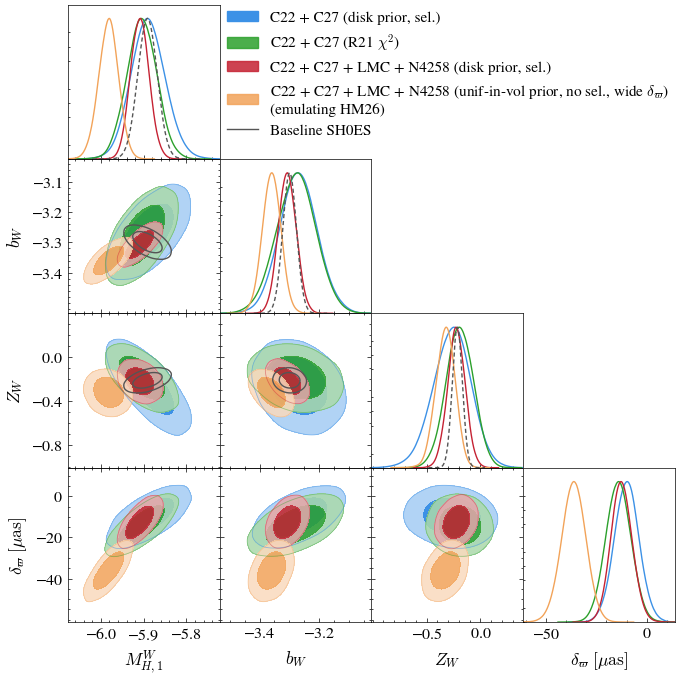

In [7]:
# Load SH0ES baseline chain and extract PLR parameters
shoes_path = join(RESULTS, "baseline_SH0ES", "samples.hdf5")
with h5py.File(shoes_path, "r") as f:
    q_free_shoes = f["q_free"][:]

shoes_samples = {
    "M_H_1": q_free_shoes[:, 38],
    "b_W": q_free_shoes[:, 37] - 3.285,
    "Z_W": q_free_shoes[:, 43],
    "delta_pi": np.full(len(q_free_shoes), np.nan),
}

with plt.style.context(["science"]):
    plot_corner_getdist(
        [load_samples("sel"), load_samples("R21"),
         load_samples("fiducial"),
         load_samples("nosel+vol+anc+wdpi"),
         shoes_samples],
        keys=["M_H_1", "b_W", "Z_W", "delta_pi"],
        labels=[run_label("sel"),
                run_label("R21"),
                run_label("fiducial"),
                run_label("nosel+vol+anc+wdpi") + "\n(emulating HM26)",
                "Baseline SH0ES"],
        cols=["#3c91e6", "#2ca02c", "#c52233", "#f2a359", "#555555"],
        linestyles=["-", "-", "-", "-", "--"],
        filled=[True, True, True, True, False],
        scales={"delta_pi": 1000},
        fontsize=16,
        legend_fontsize=14.5,
        fig_width_inch=7,
        filename=join(FIGDIR, "corner_fiducial.pdf"),
    )

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


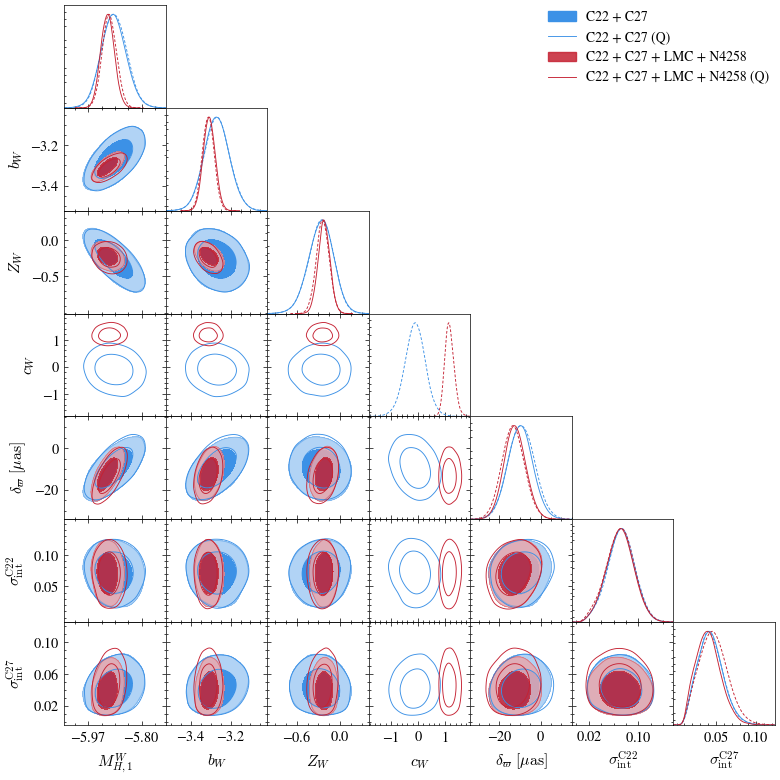

In [9]:
with plt.style.context(["science"]):
    plot_corner_getdist(
        [load_samples("sel"), load_samples("Q"),
         load_samples("fiducial"), load_samples("Q+anc")],
        keys=["M_H_1", "b_W", "Z_W", "c_W", "delta_pi",
              "sigma_int_C22", "sigma_int_C27"],
        labels=["C22 + C27", "C22 + C27 (Q)",
                "C22 + C27 + LMC + N4258",
                "C22 + C27 + LMC + N4258 (Q)"],
        cols=["#3c91e6", "#3c91e6", "#c52233", "#c52233"],
        linestyles=["-", "--", "-", "--"],
        filled=[True, False, True, False],
        scales={"delta_pi": 1000},
        fontsize=16,
        legend_fontsize=14.5,
        fig_width_inch=8,
        filename=join(FIGDIR, "corner_Q.pdf"),
    )

## 4. Distance and scatter diagnostics

### Intrinsic scatter comparison

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


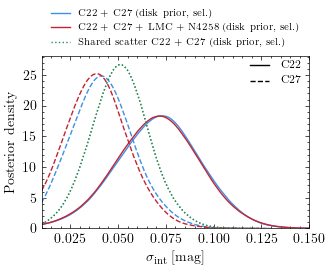

In [10]:
from getdist import MCSamples

tags = ["sel", "fiducial", "shared_noanc"]
campaigns = ["C22", "C27"]
cols = {"sel": "#3c91e6", "fiducial": "#c52233", "shared_noanc": "#2e8b57"}
# Per-tag line style: solid/dashed for C22/C27, dotted for shared (single sigma_int)
tag_ls = {"sel": {}, "fiducial": {}, "shared_noanc": {"C22": ":", "C27": ":"}}
ls_default = {"C22": "-", "C27": "--"}

BOUND = 0.01

with plt.style.context(["science"]):
    fig, ax = plt.subplots(figsize=(3.5, 2.9))

    for tag in tags:
        samples = load_samples(tag)
        for camp in campaigns:
            key = f"sigma_int_{camp}" if f"sigma_int_{camp}" in samples else "sigma_int"
            arr = samples[key].flatten()
            mc = MCSamples(
                samples=arr[:, None], names=[key], labels=[key],
                ranges={key: [BOUND, None]})
            density = mc.get1DDensity(key)
            density.normalize()
            linestyle = tag_ls.get(tag, {}).get(camp, ls_default[camp])
            ax.plot(density.x, density.P, color=cols[tag], ls=linestyle)

    # Legend: run labels
    from matplotlib.lines import Line2D
    legend_ls = {"sel": "-", "fiducial": "-", "shared_noanc": ":"}
    run_handles = [
        Line2D([], [], color=cols[t], ls=legend_ls[t], label=run_label(t))
        for t in tags
    ]
    ax.legend(handles=run_handles, fontsize=7, loc="lower center",
              bbox_to_anchor=(0.5, 1.0), ncol=1, frameon=False)

    # Top-right annotation: line style for C22/C27
    trans = ax.transAxes
    y1, y2 = 0.95, 0.86
    ax.plot([0.78, 0.85], [y1, y1], ls="-", color="k", lw=1,
            transform=trans, clip_on=False)
    ax.text(0.97, y1, "C22", transform=trans, fontsize=8,
            ha="right", va="center")
    ax.plot([0.78, 0.85], [y2, y2], ls="--", color="k", lw=1,
            transform=trans, clip_on=False)
    ax.text(0.97, y2, "C27", transform=trans, fontsize=8,
            ha="right", va="center")

    ax.set_xlabel(r"$\sigma_{\rm int} \; [{\rm mag}]$")
    ax.set_ylabel("Posterior density")
    ax.set_xlim(BOUND, 0.15)
    ax.set_ylim(0, None)

    plt.tight_layout()
    fig.savefig(join(FIGDIR, "scatter_comparison.pdf"), dpi=500,
                bbox_inches="tight")
    plt.show()

### Per-star distance modulus comparison

In [12]:
import sys
sys.path.insert(0, "..")
from candel.pvdata.mwcepheids import CepheidData

config = to_mwcepheids_config(load_config("../scripts/config.toml", replace_los_prior=False))
config["data"]["which_subset"] = None

# Match whatever the runs used: read star count from a reference sample file
import h5py as _h5
with _h5.File(hdf5_path("sel"), "r") as _f:
    _nc22_run = _f["samples/d_C22"].shape[1]
    _nc27_run = _f["samples/d_C27"].shape[1]

# If runs excluded stars, ensure data does too
if _nc22_run < 44:
    config["data"]["exclude_stars"] = config["data"].get("exclude_stars", ["S-VUL", "SV-VUL"])
else:
    config["data"]["exclude_stars"] = []

data = CepheidData(config)

mask_c22 = np.asarray(data.is_c22)
mask_c27 = np.asarray(data.is_c27)
assert mask_c22.sum() == _nc22_run, f"C22 mismatch: data={mask_c22.sum()}, samples={_nc22_run}"
assert mask_c27.sum() == _nc27_run, f"C27 mismatch: data={mask_c27.sum()}, samples={_nc27_run}"

names_c22, names_c27 = data.names[mask_c22], data.names[mask_c27]
mW_c22, mW_c27 = np.asarray(data.mW_H[mask_c22]), np.asarray(data.mW_H[mask_c27])
logP_c22, logP_c27 = np.asarray(data.logP[mask_c22]), np.asarray(data.logP[mask_c27])
OH_c22, OH_c27 = np.asarray(data.OH[mask_c22]), np.asarray(data.OH[mask_c27])

# SH0ES baseline PLR-predicted distance modulus per star
M0, bW, ZW = -5.894, -3.299, -0.217
mu_ref_c22 = mW_c22 - (M0 + bW * (logP_c22 - 1) + ZW * OH_c22)
mu_ref_c27 = mW_c27 - (M0 + bW * (logP_c27 - 1) + ZW * OH_c27)

# Combine C22 + C27, sort alphabetically
all_names = np.concatenate([names_c22, names_c27])
all_mu_ref = np.concatenate([mu_ref_c22, mu_ref_c27])
sort_idx = np.argsort(all_names)
all_names = all_names[sort_idx]
all_mu_ref = all_mu_ref[sort_idx]
n_mw = len(all_names)

print(f"C22: {mask_c22.sum()}, C27: {mask_c27.sum()}, total: {n_mw}")

2026-03-03 07:31:45 ============================================================
2026-03-03 07:31:45 Model Configuration
2026-03-03 07:31:45 ============================================================
2026-03-03 07:31:45   Model type      : forward
2026-03-03 07:31:45   Distance prior  : disk
2026-03-03 07:31:45   Scatter         : per-campaign
2026-03-03 07:31:45   Q index         : disabled
2026-03-03 07:31:45   Spiral arms     : disabled
2026-03-03 07:31:45 ------------------------------------------------------------
2026-03-03 07:31:45 C22 Selection
2026-03-03 07:31:45 ------------------------------------------------------------
2026-03-03 07:31:45   mW selection    : ENABLED
2026-03-03 07:31:45   mW_max          : infer
2026-03-03 07:31:45   mW_width        : 0.500
2026-03-03 07:31:45   AH selection    : disabled
2026-03-03 07:31:45   pi selection    : ENABLED
2026-03-03 07:31:45   pi_min          : infer
2026-03-03 07:31:45   pi_smooth       : True
2026-03-03 07:31:45   pi_width

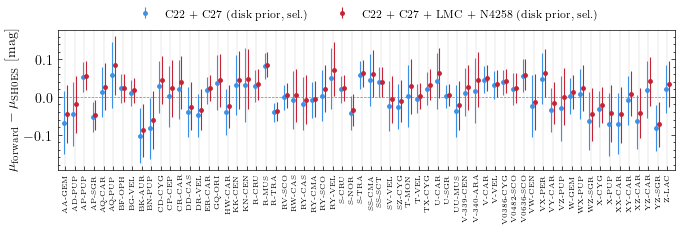

In [13]:
compare_tags = [("sel", "#3c91e6"), ("fiducial", "#c52233")]
dx = 0.15

with plt.style.context(["science"]):
    fig, ax = plt.subplots(figsize=(7, 2.5))

    for ix in range(n_mw):
        ax.axvline(ix, color="grey", lw=0.15, alpha=0.8, zorder=0)

    for i, (tag, col) in enumerate(compare_tags):
        offset = dx * (2 * i - 1)
        samples = load_samples(tag)
        d_c22, d_c27 = samples["d_C22"], samples["d_C27"]
        mu_c22 = 5 * np.log10(d_c22) + 10
        mu_c27 = 5 * np.log10(d_c27) + 10
        mu_all = np.concatenate([mu_c22, mu_c27], axis=1)
        assert mu_all.shape[1] == n_mw, (
            f"Sample size {mu_all.shape[1]} != data size {n_mw}. "
            "Restart kernel and re-run from the top.")
        mu_all = mu_all[:, sort_idx]

        dmu = mu_all - all_mu_ref[None, :]
        mean_dmu = dmu.mean(axis=0)
        p16, p84 = np.percentile(dmu, [16, 84], axis=0)

        x_mw = np.arange(n_mw) + offset
        ax.errorbar(x_mw, mean_dmu, yerr=[mean_dmu - p16, p84 - mean_dmu],
                     fmt="o", ms=2.5, lw=0.8, color=col, label=run_label(tag))

    ax.axhline(0, color="grey", ls="--", lw=0.5, zorder=0)

    ax.set_xticks(range(n_mw))
    ax.set_xticklabels(all_names, rotation=90, fontsize=5)
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.tick_params(axis="x", which="both", top=False)
    ax.set_ylabel(r"$\mu_{\rm forward} - \mu_{\rm SH0ES}$ [mag]")
    ax.set_xlim(-0.8, n_mw - 0.2)

    ax.legend(fontsize=8, loc="lower center", bbox_to_anchor=(0.5, 1.0),
              ncol=2, frameon=False)

    plt.tight_layout()
    fig.savefig(join(FIGDIR, "distance_comparison.pdf"), dpi=500,
                bbox_inches="tight")
    plt.show()

C22: mu = 0.0041, sigma = 0.0419, p_KS(zero-mean) = 0.292
C27: mu = 0.0246, sigma = 0.0304, p_KS(zero-mean) = 0.001


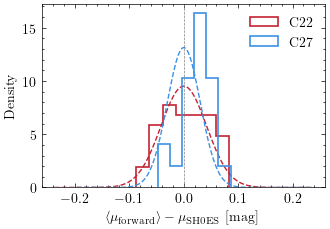

In [14]:
from scipy.stats import norm, kstest

tag = "fiducial"
samples = load_samples(tag)
d_c22, d_c27 = samples["d_C22"], samples["d_C27"]
mu_c22 = 5 * np.log10(d_c22) + 10
mu_c27 = 5 * np.log10(d_c27) + 10

# Residuals per campaign (no sorting needed)
dmu_c22 = (mu_c22 - mu_ref_c22[None, :]).mean(axis=0)
dmu_c27 = (mu_c27 - mu_ref_c27[None, :]).mean(axis=0)

camp_data = [
    ("C22", dmu_c22, "#c52233"),
    ("C27", dmu_c27, "#3c91e6"),
]

with plt.style.context(["science"]):
    fig, ax = plt.subplots(figsize=(3.5, 2.5))

    for camp, dmu, col in camp_data:
        mu_fit, sigma_fit = norm.fit(dmu)
        ks_stat, ks_p = kstest(dmu, "norm", args=(0, sigma_fit))
        print(f"{camp}: mu = {mu_fit:.4f}, sigma = {sigma_fit:.4f}, "
              f"p_KS(zero-mean) = {ks_p:.3f}")

        ax.hist(dmu, bins="auto", histtype="step", lw=1.2, color=col,
                density=True, label=camp)

        x = np.linspace(dmu.min() - 0.15, dmu.max() + 0.15, 200)
        ax.plot(x, norm.pdf(x, 0, sigma_fit), ls="--", lw=1, color=col)

    ax.axvline(0, color="grey", ls="--", lw=0.5)
    ax.set_xlabel(r"$\langle\mu_{\rm forward}\rangle - \mu_{\rm SH0ES}$ [mag]")
    ax.set_ylabel("Density")
    ax.legend(frameon=False)

    plt.tight_layout()
    fig.savefig(join(FIGDIR, "distance_residual_hist.pdf"), dpi=500,
                bbox_inches="tight")
    plt.show()

## 5. Q-index analysis

2026-03-03 07:32:21 ============================================================
2026-03-03 07:32:21 Model Configuration
2026-03-03 07:32:21 ============================================================
2026-03-03 07:32:21   Model type      : forward
2026-03-03 07:32:21   Distance prior  : disk
2026-03-03 07:32:21   Scatter         : per-campaign
2026-03-03 07:32:21   Q index         : disabled
2026-03-03 07:32:21   Spiral arms     : disabled
2026-03-03 07:32:21 ------------------------------------------------------------
2026-03-03 07:32:21 C22 Selection
2026-03-03 07:32:21 ------------------------------------------------------------
2026-03-03 07:32:21   mW selection    : ENABLED
2026-03-03 07:32:21   mW_max          : infer
2026-03-03 07:32:21   mW_width        : 0.500
2026-03-03 07:32:21   AH selection    : disabled
2026-03-03 07:32:21   pi selection    : ENABLED
2026-03-03 07:32:21   pi_min          : infer
2026-03-03 07:32:21   pi_smooth       : True
2026-03-03 07:32:21   pi_width

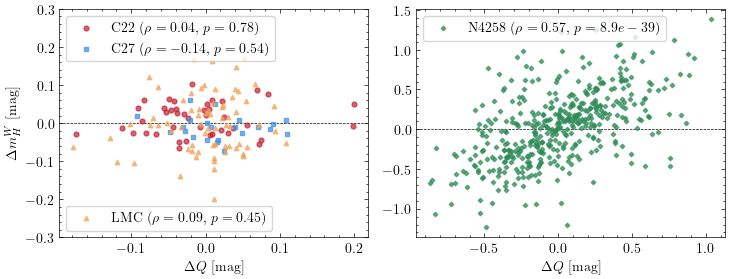

In [15]:
# Magnitude and parallax residuals (no-Q fit) vs Q index
from scipy.stats import spearmanr
from candel.pvdata.mwcepheids import CepheidData

_config = to_mwcepheids_config(load_config("../scripts/config.toml", replace_los_prior=False))
_config["data"]["which_subset"] = None
_config["model"]["anchors"] = ["NGC4258", "LMC"]

# Match star count to the fiducial run
with h5py.File(hdf5_path("fiducial"), "r") as _f:
    _grp = _f["samples"] if "samples" in _f else _f
    _nc22 = _grp["d_C22"].shape[1]
if _nc22 < 44:
    _config["data"]["exclude_stars"] = _config["data"].get(
        "exclude_stars", ["S-VUL", "SV-VUL"])
else:
    _config["data"]["exclude_stars"] = []
_data = CepheidData(_config)

# MW data
_m22 = np.asarray(_data.is_c22)
_m27 = np.asarray(_data.is_c27)
Q_c22 = np.asarray(_data.Q[_m22])
Q_c27 = np.asarray(_data.Q[_m27])
mW_c22 = np.asarray(_data.mW_H[_m22])
mW_c27 = np.asarray(_data.mW_H[_m27])
logP_c22 = np.asarray(_data.logP[_m22])
logP_c27 = np.asarray(_data.logP[_m27])
OH_c22 = np.asarray(_data.OH[_m22])
OH_c27 = np.asarray(_data.OH[_m27])
pi_obs_c22 = np.asarray(_data.pi_EDR3[_m22])
pi_obs_c27 = np.asarray(_data.pi_EDR3[_m27])

# Anchor data — extract Q (handling partial coverage for N4258)
_anc_n4258 = _data.anchor_data["NGC4258"]
_anc_lmc = _data.anchor_data["LMC"]

def _get_anchor_Q(anc):
    """Get mean-subtracted Q and validity mask for an anchor."""
    if anc.Q is not None:
        return np.asarray(anc.Q), np.ones(anc.n_stars, dtype=bool)
    if hasattr(anc, "_Q_raw"):
        mask = np.asarray(anc._Q_valid_mask)
        Q_raw = np.asarray(anc._Q_raw)[mask]
        return Q_raw - Q_raw.mean(), mask
    return None, None

Q_n4258, _qmask_n4258 = _get_anchor_Q(_anc_n4258)
Q_lmc, _qmask_lmc = _get_anchor_Q(_anc_lmc)

tag = "fiducial"
samples = load_samples(tag)
M_H_1 = samples["M_H_1"].mean()
b_W = samples["b_W"].mean()
Z_W = samples["Z_W"].mean()
delta_pi = samples["delta_pi"].mean()

# MW magnitude residuals
d_c22_mean = samples["d_C22"].mean(axis=0)
d_c27_mean = samples["d_C27"].mean(axis=0)
mu_pred_c22 = M_H_1 + b_W * (logP_c22 - 1) + Z_W * OH_c22 + 5 * np.log10(d_c22_mean) + 10
mu_pred_c27 = M_H_1 + b_W * (logP_c27 - 1) + Z_W * OH_c27 + 5 * np.log10(d_c27_mean) + 10
dmag_c22 = mW_c22 - mu_pred_c22
dmag_c27 = mW_c27 - mu_pred_c27

# Anchor magnitude residuals (filter to stars with valid Q)
mu_n4258 = samples["mu_NGC4258"].mean()
mu_lmc = samples["mu_LMC"].mean()

def _anchor_mag_resid(anc, mu, qmask):
    logP = np.asarray(anc.logP)
    OH = np.asarray(anc.OH)
    mW = np.asarray(anc.mW_H)
    pred = M_H_1 + b_W * (logP - 1) + Z_W * OH + mu
    resid = mW - pred
    if qmask is not None:
        return resid[qmask]
    return resid

dmag_n4258 = _anchor_mag_resid(_anc_n4258, mu_n4258, _qmask_n4258)
dmag_lmc = _anchor_mag_resid(_anc_lmc, mu_lmc, _qmask_lmc)

# Per-population Spearman rho
print(f"{'Population':<10s} {'N':>5s} {'rho':>7s} {'p':>10s}")
print("-" * 35)
for name, Q, resid in [("C22", Q_c22, dmag_c22),
                        ("C27", Q_c27, dmag_c27),
                        ("LMC", Q_lmc, dmag_lmc),
                        ("N4258", Q_n4258, dmag_n4258)]:
    if Q is not None:
        rho, p = spearmanr(Q, resid)
        print(f"{name:<10s} {len(Q):5d} {rho:7.3f} {p:10.2g}")

with plt.style.context(["science"]):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3))

    # Left: C22 + C27 + LMC
    handles_top, handles_bot = [], []
    for Q, resid, col, marker, label, ms in [
            (Q_c22, dmag_c22, "#c52233", "o", "C22", 12),
            (Q_c27, dmag_c27, "#3c91e6", "s", "C27", 12),
            (Q_lmc, dmag_lmc, "#f2a359", "^", "LMC", 10)]:
        if Q is not None:
            rho, p = spearmanr(Q, resid)
            h = ax1.scatter(Q, resid, s=ms, color=col, marker=marker,
                            alpha=0.7,
                            label=f"{label} ($\\rho={rho:.2f}$, $p={p:.2g}$)",
                            zorder=2)
            if label in ("C22", "C27"):
                handles_top.append(h)
            else:
                handles_bot.append(h)
    ax1.axhline(0, color="k", ls="--", lw=0.5, zorder=1)
    ax1.set_ylim(-0.3, 0.3)
    ax1.set_xlabel(r"$\Delta Q$ [mag]")
    ax1.set_ylabel(r"$\Delta m^W_H$ [mag]")

    leg_top = ax1.legend(handles=handles_top,
                         labels=[h.get_label() for h in handles_top],
                         loc="upper left", frameon=True)
    ax1.add_artist(leg_top)
    ax1.legend(handles=handles_bot,
               labels=[h.get_label() for h in handles_bot],
               loc="lower left", frameon=True)

    # Right: N4258
    if Q_n4258 is not None:
        rho, p = spearmanr(Q_n4258, dmag_n4258)
        ax2.scatter(Q_n4258, dmag_n4258, s=5, color="#2e8b57", marker="D",
                    alpha=0.7,
                    label=f"N4258 ($\\rho={rho:.2f}$, $p={p:.2g}$)",
                    zorder=2)
    ax2.axhline(0, color="k", ls="--", lw=0.5, zorder=1)
    ax2.set_xlabel(r"$\Delta Q$ [mag]")
    ax2.legend(loc="upper left", frameon=True)

    plt.tight_layout()
    fig.savefig(join(FIGDIR, "residuals_vs_Q.pdf"), dpi=500,
                bbox_inches="tight")
    plt.show()

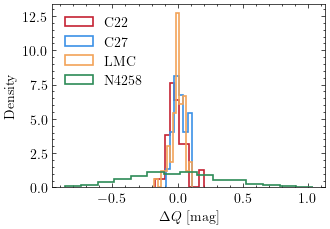

In [16]:
# Histograms of Delta Q per population
with plt.style.context(["science"]):
    fig, ax = plt.subplots(figsize=(3.5, 2.5))

    for Q, col, label in [
            (Q_c22, "#c52233", "C22"),
            (Q_c27, "#3c91e6", "C27"),
            (Q_lmc, "#f2a359", "LMC"),
            (Q_n4258, "#2e8b57", "N4258")]:
        if Q is not None:
            ax.hist(Q, bins="auto", histtype="step", lw=1.2,
                    color=col, density=True, label=label)

    ax.set_xlabel(r"$\Delta Q$ [mag]")
    ax.set_ylabel("Density")
    ax.legend(loc="upper left")

    plt.tight_layout()
    fig.savefig(join(FIGDIR, "deltaQ_histograms.pdf"), dpi=500,
                bbox_inches="tight")
    plt.show()

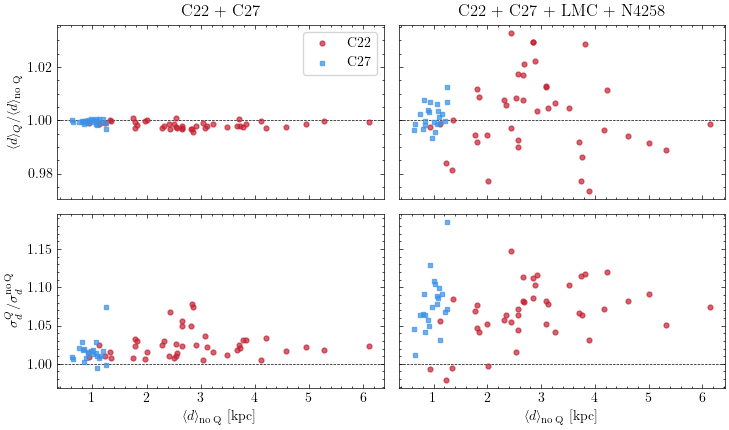

In [17]:
# Per-star distance comparison: Q vs no-Q
pairs = [
    ("sel", "Q", "C22 + C27"),
    ("fiducial", "Q+anc", "C22 + C27 + LMC + N4258"),
]

with plt.style.context(["science"]):
    fig, axes = plt.subplots(2, 2, figsize=(7.5, 4.5), sharex="col", sharey='row')

    for j, (tag_noQ, tag_Q, title) in enumerate(pairs):
        s_noQ = load_samples(tag_noQ)
        s_Q = load_samples(tag_Q)

        ax_mean = axes[0, j]
        ax_sigma = axes[1, j]

        for key, col, marker in [("d_C22", "#c52233", "o"),
                                  ("d_C27", "#3c91e6", "s")]:
            d_mean_noQ = s_noQ[key].mean(axis=0)
            d_mean_Q = s_Q[key].mean(axis=0)
            sigma_noQ = s_noQ[key].std(axis=0)
            sigma_Q = s_Q[key].std(axis=0)

            ax_mean.scatter(d_mean_noQ, d_mean_Q / d_mean_noQ, s=12,
                            color=col, marker=marker, alpha=0.7,
                            label=key.replace("d_", ""), zorder=2)
            ax_sigma.scatter(d_mean_noQ, sigma_Q / sigma_noQ, s=12,
                             color=col, marker=marker, alpha=0.7,
                             label=key.replace("d_", ""), zorder=2)

        for ax in [ax_mean, ax_sigma]:
            ax.axhline(1, color="k", ls="--", lw=0.5, zorder=1)

        ax_mean.set_title(title)
        ax_sigma.set_xlabel(r"$\langle d \rangle_{\rm no\,Q}$ [kpc]")

    axes[0, 0].legend(frameon=True)
    axes[0, 0].set_ylabel(
        r"$\langle d \rangle_{Q} / \langle d \rangle_{\rm no\,Q}$")
    axes[1, 0].set_ylabel(
        r"$\sigma_d^{Q} / \sigma_d^{\rm no\,Q}$")

    plt.tight_layout()
    fig.savefig(join(FIGDIR, "distance_Q_comparison.pdf"), dpi=500,
                bbox_inches="tight")
    plt.show()

In [18]:
# Evidence comparison: free c_W vs c_W=0 (both model Q population)
ln10 = np.log(10)

ev_pairs = [
    ("MW only",
     "forward/C22+C27_C22-mW+pi_C27-pi+mW_dprior-disk_Q_c_W=0.0",
     "forward/C22+C27_C22-mW+pi_C27-pi+mW_dprior-disk_Q"),
    ("MW + anchors",
     "forward/C22+C27_C22-mW+pi_C27-pi+mW_anc-NGC4258+LMC_dprior-disk_Q_c_W=0.0",
     "forward/C22+C27_C22-mW+pi_C27-pi+mW_anc-NGC4258+LMC_dprior-disk_Q"),
]

rows = []
for group, path_cW0, path_cWfree in ev_pairs:
    for label, path in [("$c_W = 0$", path_cW0), ("$c_W$ free", path_cWfree)]:
        fpath = join(RESULTS, path + "_marg_ev", "samples.hdf5")
        with h5py.File(fpath, "r") as f:
            gof = {k: float(f["gof"][k][()]) for k in f["gof"].keys()}
        rows.append((group, label, gof))

# Print table
print(f"{'Data':<16s} {'Model':<12s} {'BIC':>8s} {'AIC':>8s} "
      f"{'log10 Z_lap':>12s} {'log10 Z_harm':>13s}")
print("-" * 75)
for group, label, gof in rows:
    print(f"{group:<16s} {label:<12s} {gof['BIC']:8.1f} {gof['AIC']:8.1f} "
          f"{gof['lnZ_laplace'] / ln10:12.1f} {gof['lnZ_harmonic'] / ln10:13.1f}")

# Bayes factors (c_W free - c_W=0)
print()
print("Bayes factors (log10 B = log10 Z[c_W free] - log10 Z[c_W=0]):")
print("-" * 60)
for i in range(0, len(rows), 2):
    group = rows[i][0]
    for key, est in [("lnZ_laplace", "Laplace"), ("lnZ_harmonic", "Harmonic")]:
        log10B = (rows[i+1][2][key] - rows[i][2][key]) / ln10
        print(f"  {group:<16s} {est:<10s}  log10 B = {log10B:+.1f}")

Data             Model             BIC      AIC  log10 Z_lap  log10 Z_harm
---------------------------------------------------------------------------
MW only          $c_W = 0$      -489.1   -549.0        105.1         105.2
MW only          $c_W$ free     -477.3   -540.0        103.9         104.4
MW + anchors     $c_W = 0$     -1273.6  -1425.3        282.4         283.6
MW + anchors     $c_W$ free    -1312.2  -1468.4        291.5         292.7

Bayes factors (log10 B = log10 Z[c_W free] - log10 Z[c_W=0]):
------------------------------------------------------------
  MW only          Laplace     log10 B = -1.2
  MW only          Harmonic    log10 B = -0.8
  MW + anchors     Laplace     log10 B = +9.2
  MW + anchors     Harmonic    log10 B = +9.2


### JWST Q-index: corner plot and evidence comparison

In [ ]:
with plt.style.context(["science"]):
    plot_corner_getdist(
        [load_samples("Q_jwst_cW0"), load_samples("Q_jwst")],
        keys=["M_H_1", "b_W", "Z_W", "c_W", "delta_pi",
              "sigma_int_C22", "sigma_int_C27"],
        labels=["$c_W = 0$", "$c_W$ free"],
        cols=["#3c91e6", "#c52233"],
        linestyles=["-", "-"],
        filled=[True, True],
        scales={"delta_pi": 1000},
        fontsize=16,
        legend_fontsize=14.5,
        fig_width_inch=8,
        filename=join(FIGDIR, "corner_Q_jwst.pdf"),
    )

In [ ]:
# Evidence comparison: JWST Q on N4258, free c_W vs c_W=0
ln10 = np.log(10)

ev_pairs_jwst = [
    ("MW + N4258 (JWST Q)", "Q_jwst_cW0", "Q_jwst"),
]

rows = []
for group, tag_cW0, tag_cWfree in ev_pairs_jwst:
    for label, tag in [("$c_W = 0$", tag_cW0), ("$c_W$ free", tag_cWfree)]:
        with h5py.File(hdf5_path(tag), "r") as f:
            gof = {k: float(f["gof"][k][()]) for k in f["gof"].keys()}
        rows.append((group, label, gof))

print(f"{'Data':<25s} {'Model':<12s} {'BIC':>8s} {'AIC':>8s} "
      f"{'log10 Z_lap':>12s} {'log10 Z_harm':>13s}")
print("-" * 85)
for group, label, gof in rows:
    print(f"{group:<25s} {label:<12s} {gof['BIC']:8.1f} {gof['AIC']:8.1f} "
          f"{gof['lnZ_laplace'] / ln10:12.1f} {gof['lnZ_harmonic'] / ln10:13.1f}")

print()
print("Bayes factors (log10 B = log10 Z[c_W free] - log10 Z[c_W=0]):")
print("-" * 60)
for i in range(0, len(rows), 2):
    group = rows[i][0]
    for key, est in [("lnZ_laplace", "Laplace"), ("lnZ_harmonic", "Harmonic")]:
        log10B = (rows[i+1][2][key] - rows[i][2][key]) / ln10
        print(f"  {group:<25s} {est:<10s}  log10 B = {log10B:+.1f}")

## 6. Posterior predictive checks

In [19]:
N_PPC_SAMPLES = 1000
rng_ppc = np.random.default_rng(42)

ppc_runs = {
    "fiducial": {
        "col": "#3c91e6", "histtype": "bar",
        "label": r"$\mathrm{C22\,+\,C27\,+\,LMC\,+\,N4258}$" + "\n" + r"$\mathrm{(disk\,prior,\,sel.)}$"},
    "nosel+vol+anc": {
        "col": "#f2a359", "histtype": "step",
        "label": r"$\mathrm{C22\,+\,C27\,+\,LMC\,+\,N4258}$" + "\n" + r"$\mathrm{(unif\mbox{-}in\mbox{-}vol\,prior,\,no\,sel.)}$"},
}

ppcs, ppc_labels, ppc_cols, ppc_ht = [], [], [], []
for tag, opts in ppc_runs.items():
    run_dir = join(RESULTS, RUNS[tag][1])
    cfg = to_mwcepheids_config(load_config(join(run_dir, "config.toml"), replace_los_prior=False))
    dat = CepheidData(cfg)

    all_samples = load_samples(tag)
    n_total = len(all_samples["M_H_1"])
    idx = rng_ppc.choice(n_total, N_PPC_SAMPLES, replace=False)
    thin_samples = {k: v[idx] for k, v in all_samples.items()}

    ppcs.append(generate_ppc(thin_samples, dat, cfg))
    ppc_labels.append(opts["label"])
    ppc_cols.append(opts["col"])
    ppc_ht.append(opts["histtype"])

2026-03-03 07:32:31 ============================================================
2026-03-03 07:32:31 Model Configuration
2026-03-03 07:32:31 ============================================================
2026-03-03 07:32:31   Model type      : forward
2026-03-03 07:32:31   Distance prior  : disk
2026-03-03 07:32:31   Scatter         : per-campaign
2026-03-03 07:32:31   Q index         : disabled
2026-03-03 07:32:31   Spiral arms     : disabled
2026-03-03 07:32:31 ------------------------------------------------------------
2026-03-03 07:32:31 C22 Selection
2026-03-03 07:32:31 ------------------------------------------------------------
2026-03-03 07:32:31   mW selection    : ENABLED
2026-03-03 07:32:31   mW_max          : infer
2026-03-03 07:32:31   mW_width        : 0.500
2026-03-03 07:32:31   AH selection    : disabled
2026-03-03 07:32:31   pi selection    : ENABLED
2026-03-03 07:32:31   pi_min          : infer
2026-03-03 07:32:31   pi_smooth       : True
2026-03-03 07:32:31   pi_width

PPC (C22):   0%|          | 0/42000 [00:00<?, ?samples/s]

2026-03-03 07:32:37   PPC acceptance: 59762/2066344 (2.9%), batches=2
2026-03-03 07:32:37 PPC (C27): d = [0.31, 2.00] kpc, prior = disk
2026-03-03 07:32:37   C27 pi selection (pi_min = 0.8)
2026-03-03 07:32:37   C27 mW lower selection (mW_min = infer)
2026-03-03 07:32:37   Loaded 5000 MC sightlines from spiral cache


PPC (C27):   0%|          | 0/22000 [00:00<?, ?samples/s]

2026-03-03 07:32:37   PPC acceptance: 31349/110000 (28.5%), batches=1
2026-03-03 07:32:37 ============================================================
2026-03-03 07:32:37 Model Configuration
2026-03-03 07:32:37 ============================================================
2026-03-03 07:32:37   Model type      : forward
2026-03-03 07:32:37   Distance prior  : volume
2026-03-03 07:32:37   Scatter         : per-campaign
2026-03-03 07:32:37   Q index         : disabled
2026-03-03 07:32:37   Spiral arms     : disabled
2026-03-03 07:32:37 ------------------------------------------------------------
2026-03-03 07:32:37 C22 Selection
2026-03-03 07:32:37 ------------------------------------------------------------
2026-03-03 07:32:37   Status          : disabled
2026-03-03 07:32:37 ------------------------------------------------------------
2026-03-03 07:32:37 C27 Selection
2026-03-03 07:32:37 ------------------------------------------------------------
2026-03-03 07:32:37   Status          : d

PPC (C22):   0%|          | 0/42000 [00:00<?, ?samples/s]

2026-03-03 07:32:37   PPC acceptance: 210000/210000 (100.0%), batches=1
2026-03-03 07:32:37 PPC (C27): d = [0.31, 2.00] kpc, prior = disk
2026-03-03 07:32:37   No selection applied
2026-03-03 07:32:37   Loaded 5000 MC sightlines from spiral cache


PPC (C27):   0%|          | 0/22000 [00:00<?, ?samples/s]

2026-03-03 07:32:37   PPC acceptance: 110000/110000 (100.0%), batches=1


2026-03-03 07:32:42   $\mathrm{C22\,+\,C27\,+\,LMC\,+\,N4258}$
$\mathrm{(disk\,prior,\,sel.)}$: KS(mW) p=0.3269, KS(pi) p=0.2210, KS(logP) p=0.9889
2026-03-03 07:32:42   $\mathrm{C22\,+\,C27\,+\,LMC\,+\,N4258}$
$\mathrm{(unif\mbox{-}in\mbox{-}vol\,prior,\,no\,sel.)}$: KS(mW) p=0.0000, KS(pi) p=0.0000, KS(logP) p=0.9704


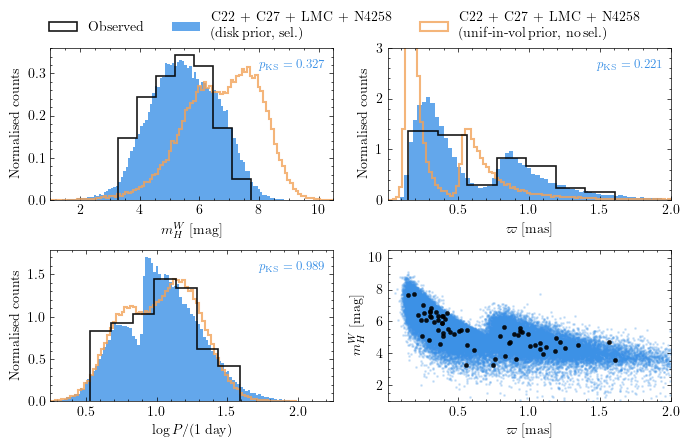

In [20]:
fig = plot_ppc(
    ppcs, labels=ppc_labels, cols=ppc_cols, histtypes=ppc_ht,
    show_ks=[0], show_scatter=[0], pi_ymax=3,
    mW_xlim=(1., 10.5), pi_xlim=(0.01, 2), logP_xlim=(0.25, 2.25),
    ncols=2, figsize=(7, 4.5),
    filename=join(FIGDIR, "PPC_fiducial.pdf"))
display(fig)

## 7. Appendix

### Individual campaign results

In [21]:
appendix_tags = [
    # C22 only
    "C22_sel", "C22_nosel", "C22_sel+anc", "C22_nosel+anc", "R21_C22", "R21_C22+anc",
    # C27 only
    "C27_sel", "C27_nosel", "C27_sel+anc", "C27_nosel+anc", "R21_C27", "R21_C27+anc",
    # C22+C27
    "sel", "nosel", "fiducial", "nosel+anc", "R21",
]

APPENDIX_KEYS = ["M_H_1", "b_W", "Z_W", "delta_pi"]

print(f"{'Model':<45s} {'M_H_1':>18s} {'b_W':>18s} {'Z_W':>18s} {'delta_pi':>18s}")
print("-" * 120)

for tag in appendix_tags:
    stats = summarise(tag, APPENDIX_KEYS)
    row = f"{run_label(tag):<45s}"
    for k in APPENDIX_KEYS:
        if k in stats:
            s = stats[k]
            row += f"  {s['mean']:>7.3f} +/- {s['std']:.3f}"
        else:
            row += f"  {'---':>18s}"
    print(row)

Model                                                      M_H_1                b_W                Z_W           delta_pi
------------------------------------------------------------------------------------------------------------------------
C22 (disk prior, sel.)                          -5.753 +/- 0.052   -3.508 +/- 0.115   -0.319 +/- 0.200    0.001 +/- 0.007
C22 (disk prior, no sel.)                       -5.834 +/- 0.050   -3.512 +/- 0.117   -0.305 +/- 0.201   -0.013 +/- 0.007
C22 + LMC + N4258 (disk prior, sel.)            -5.865 +/- 0.026   -3.309 +/- 0.032   -0.083 +/- 0.111   -0.006 +/- 0.006
C22 + LMC + N4258 (disk prior, no sel.)         -5.905 +/- 0.027   -3.320 +/- 0.032   -0.191 +/- 0.115   -0.017 +/- 0.006
C22 (R21 $\chi^2$)                              -5.790 +/- 0.050   -3.483 +/- 0.122   -0.264 +/- 0.172   -0.005 +/- 0.007
C22 + LMC + N4258 (R21 $\chi^2$)                -5.878 +/- 0.027   -3.313 +/- 0.032   -0.096 +/- 0.109   -0.011 +/- 0.006
C27 (disk prior, sel.)   

### Individual campaign corner plots

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


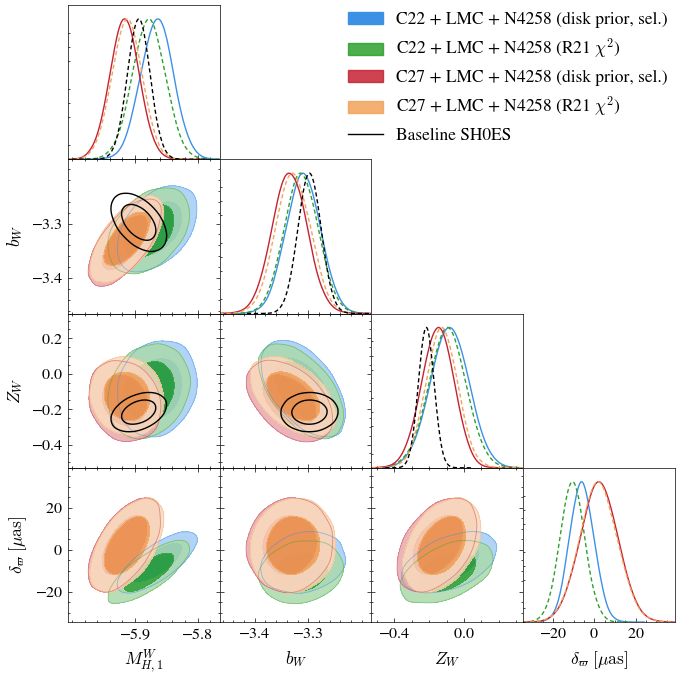

In [15]:
# Combined: C22 vs C27 (forward + R21, each with LMC+N4258 anchors)
shoes_path = join(RESULTS, "baseline_SH0ES", "samples.hdf5")
with h5py.File(shoes_path, "r") as f:
    q_free_shoes = f["q_free"][:]

shoes_samples = {
    "M_H_1": q_free_shoes[:, 38],
    "b_W": q_free_shoes[:, 37] - 3.285,
    "Z_W": q_free_shoes[:, 43],
    "delta_pi": np.full(len(q_free_shoes), np.nan),
}

with plt.style.context(["science"]):
    plot_corner_getdist(
        [load_samples("C22_sel+anc"), load_samples("R21_C22+anc"),
         load_samples("C27_sel+anc"), load_samples("R21_C27+anc"),
         shoes_samples],
        keys=["M_H_1", "b_W", "Z_W", "delta_pi"],
        labels=[run_label("C22_sel+anc"),
                run_label("R21_C22+anc"),
                run_label("C27_sel+anc"),
                run_label("R21_C27+anc"),
                "Baseline SH0ES"],
        cols=["#3c91e6", "#2ca02c", "#c52233", "#f2a359", "k"],
        linestyles=["-", "--", "-", "--", "--"],
        filled=[True, True, True, True, False],
        scales={"delta_pi": 1000},
        fontsize=16,
        legend_fontsize=16,
        fig_width_inch=7,
        filename=join(FIGDIR, "corner_C22_C27.pdf"),
    )